# Screenshot to Anki — Pipeline Exploration

This notebook walks through the full OCR pipeline step by step:
1. Load a screenshot
2. Preprocess with OpenCV
3. Run OCR with EasyOCR + visualize bounding boxes
4. Detect layout type
5. Parse source/translation
6. Generate example sentences via LLM

## 0. Setup

In [6]:
import sys
import os
from pathlib import Path
from glob import glob
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from PIL import Image

# Add project root to path
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(BASE_DIR)

from src.scanner.preprocessor import preprocess
from src.scanner.ocr_engine import extract_text
from src.scanner.gallery_scanner import scan_gallery
from src.parser.layout_detector import detect_layout
from src.parser.translator_parser import parse_translation
from src.enrichment.phrase_generator import generate_examples

print('All imports OK')
print('BASE_DIR:', BASE_DIR)


All imports OK
BASE_DIR: C:\Генри\screenshot-to-anki


In [7]:
# Pick one sample screenshot to work with
files = glob(os.path.join(BASE_DIR, 'data/samples/*.jpg'))
print(f'Found {len(files)} screenshots')

SAMPLE = files[0]  # change index to try different screenshots
print('Using:', Path(SAMPLE).name)

Found 20 screenshots
Using: photo_2026-03-10_17-23-23.jpg


## 1. Original Screenshot

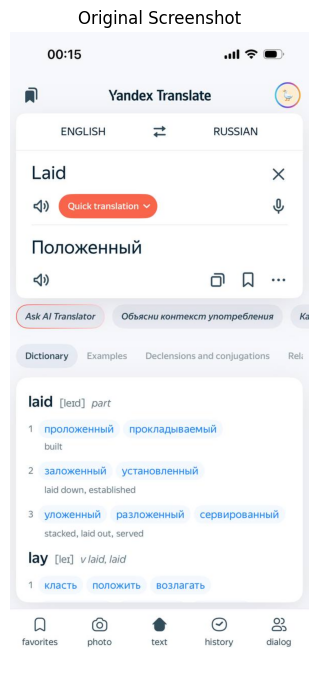

Image shape: (1280, 590, 3)  (H x W x C)


In [8]:
original = np.array(Image.open(SAMPLE))

plt.figure(figsize=(4, 7))
plt.imshow(original)
plt.title('Original Screenshot')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Image shape: {original.shape}  (H x W x C)')

## 2. Preprocessing

We convert to grayscale and boost contrast so EasyOCR reads text more accurately.

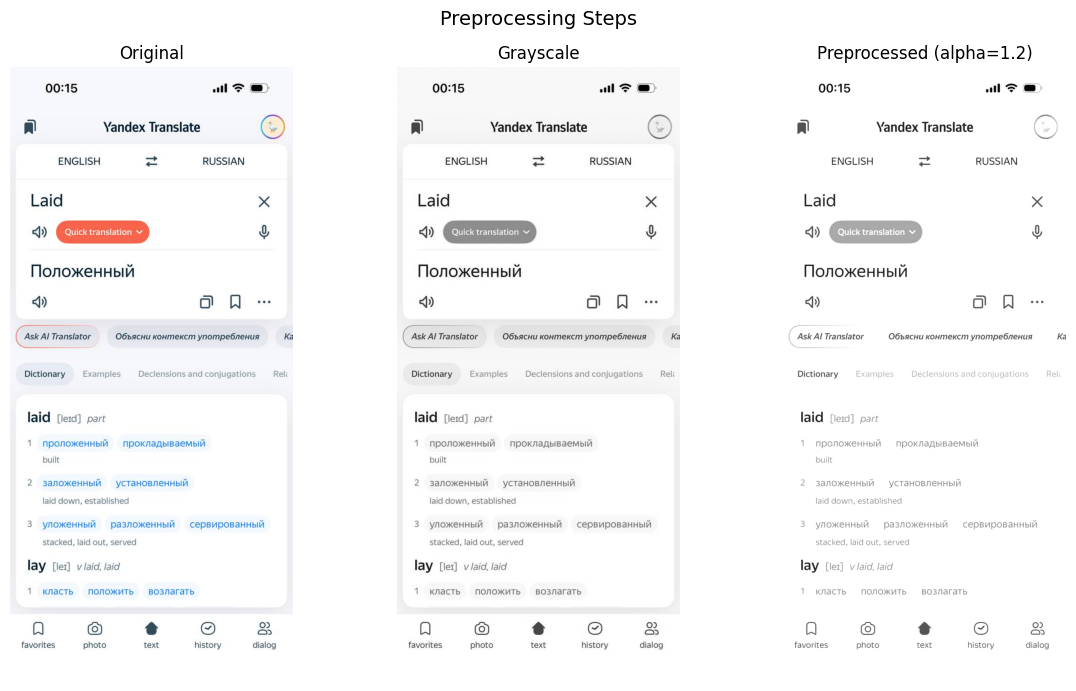

In [9]:
# Grayscale only (no contrast boost) for comparison
gray_only = cv.cvtColor(original, cv.COLOR_RGB2GRAY)

# Full preprocessing
preprocessed = preprocess(SAMPLE)

fig, axes = plt.subplots(1, 3, figsize=(12, 7))

axes[0].imshow(original)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(gray_only, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(preprocessed, cmap='gray')
axes[2].set_title('Preprocessed (alpha=1.2)')
axes[2].axis('off')

plt.suptitle('Preprocessing Steps', fontsize=14)
plt.tight_layout()
plt.show()

## 3. OCR — Text Detection & Recognition

EasyOCR returns a list of `(bbox, text, confidence)` tuples.
Each `bbox` contains 4 corner points of the detected text region.

In [10]:
ocr_results = extract_text(preprocessed)
print(f'Detected {len(ocr_results)} text regions\n')

for bbox, text, confidence in ocr_results:
    print(f'[{confidence:.2f}] {text}')

C:\Генри\screenshot-to-anki\venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected 39 text regions

[0.99] 00:15
[1.00] Yandex Translate
[1.00] ENGLISH
[1.00] RUSSIAN
[1.00] Laid
[0.80] 4))
[0.90] Quick translation
[1.00] Положенный
[0.94] 4))
[0.85] Ask Al Translator
[0.56] Объяснu конmeкcm уnomребленця
[1.00] Dictionary
[1.00] Examples
[0.94] Declensions and
[1.00] conjugations
[0.99] Rel;
[0.62] laid [leid] part
[1.00] проложенный
[1.00] прокладываемый
[1.00] built
[1.00] заложенный
[1.00] установленный
[0.79] Iaid down; established
[1.00] уложенный
[1.00] разложенный
[1.00] сервированный
[0.52] stacked , Iaid out
[1.00] served
[0.72] [leт]
[0.53] v laid; laid
[0.92] класть
[0.28] положиТь
[1.00] возлагать
[1.00] favorites
[1.00] photo
[1.00] text
[1.00] history
[1.00] dialog
[0.34] lay


### 3.1 Visualize Bounding Boxes

We draw each detected text region on the image. Color indicates confidence:
- 🟢 Green — high confidence (≥ 0.9)
- 🟡 Yellow — medium confidence (0.7–0.9)
- 🔴 Red — low confidence (< 0.7)

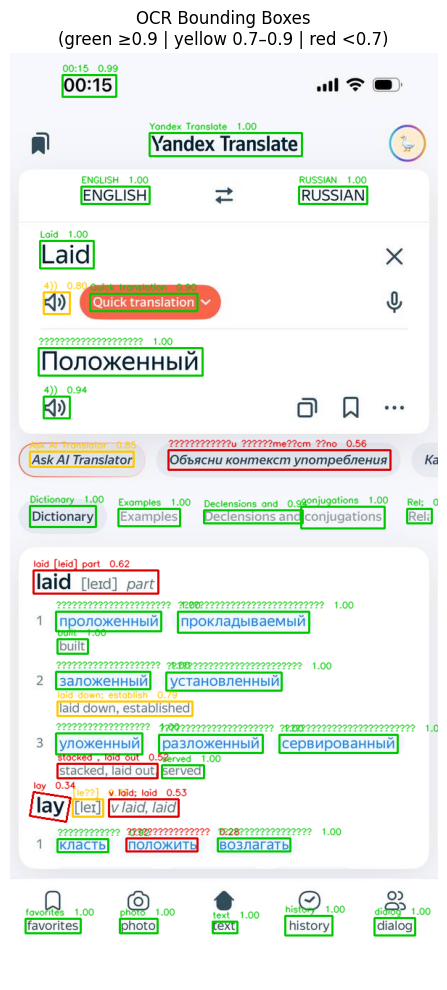

In [11]:
def draw_bboxes(image_path: str, ocr_results: list) -> np.ndarray:
    """Draw OCR bounding boxes on original image with confidence-based coloring."""
    img = np.array(Image.open(image_path)).copy()
    
    # Convert RGB to BGR for OpenCV drawing
    img_bgr = cv.cvtColor(img, cv.COLOR_RGB2BGR)
    
    for bbox, text, confidence in ocr_results:
        # Convert bbox points to integer numpy array
        pts = np.array(bbox, dtype=np.int32)
        
        # Color by confidence: green / yellow / red
        if confidence >= 0.9:
            color = (0, 200, 0)    # green
        elif confidence >= 0.7:
            color = (0, 200, 255)  # yellow
        else:
            color = (0, 0, 220)    # red
        
        # Draw polygon around text region
        cv.polylines(img_bgr, [pts], isClosed=True, color=color, thickness=2)
        
        # Put text label above bbox
        x, y = pts[0]
        label = f'{text[:20]}  {confidence:.2f}'
        cv.putText(img_bgr, label, (x, max(y - 5, 10)),
                   cv.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv.LINE_AA)
    
    # Convert back to RGB for matplotlib
    return cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)


annotated = draw_bboxes(SAMPLE, ocr_results)

plt.figure(figsize=(6, 10))
plt.imshow(annotated)
plt.title('OCR Bounding Boxes\n(green ≥0.9 | yellow 0.7–0.9 | red <0.7)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Layout Detection

We identify which translator app the screenshot came from based on OCR marker words.

In [12]:
layout = detect_layout(ocr_results)
print(f'Detected layout: {layout}')

layout_descriptions = {
    'yandex_new': 'Yandex Translate — new white UI (has "Quick translation" button)',
    'yandex_old': 'Yandex Translate — old yellow UI (has "Related words" tab)',
    'google':     'Google Translate',
    'unknown':    'Unknown layout — will be skipped',
}
print(layout_descriptions.get(layout, 'N/A'))

Detected layout: yandex_new
Yandex Translate — new white UI (has "Quick translation" button)


## 5. Parsing — Extract Source & Translation

Based on the detected layout we apply the corresponding parser.
The parser uses Y-coordinates of bounding boxes to find the source word and its translation.

In [13]:
result = parse_translation(ocr_results)
print('Parsed result:')
print(f'  source:      {result["source"]}')
print(f'  translation: {result["translation"]}')

Parsed result:
  source:      Laid
  translation: Положенный


### 5.1 Visualize Y-coordinate Logic

This plot shows why we use Y-coordinates: source and translation are located at specific vertical positions relative to the separator element ("Quick translation" button or "Dictionary" tab).

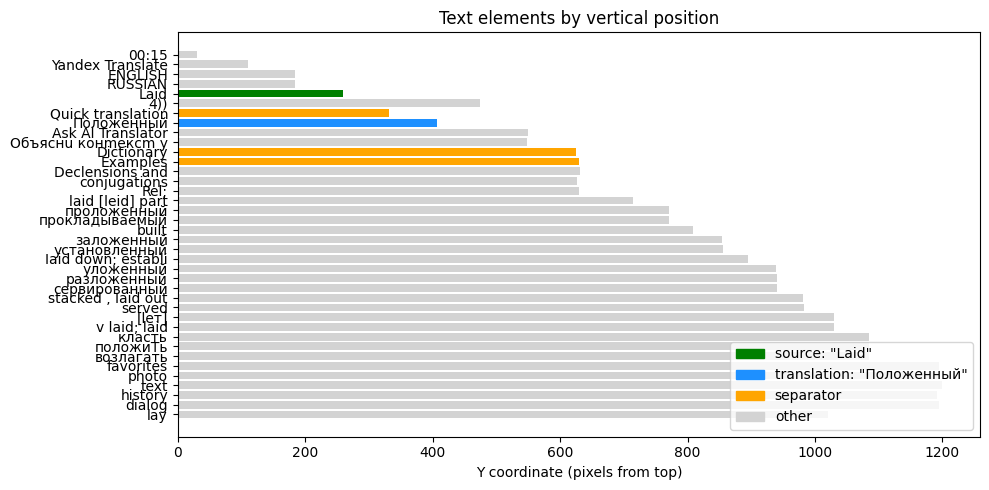

In [14]:
SEPARATOR_WORDS = {'Quick translation', 'Dictionary', 'Examples', 'Related words'}

y_coords = []
labels = []
colors = []

for bbox, text, confidence in ocr_results:
    y = bbox[0][1]
    y_coords.append(y)
    short = text[:18]
    labels.append(short)
    
    if text in SEPARATOR_WORDS:
        colors.append('orange')
    elif text == result['source']:
        colors.append('green')
    elif text == result['translation']:
        colors.append('dodgerblue')
    else:
        colors.append('lightgray')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, y_coords, color=colors)
ax.invert_yaxis()
ax.set_xlabel('Y coordinate (pixels from top)')
ax.set_title('Text elements by vertical position')

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='green',      label=f'source: "{result["source"]}"'),
    Patch(color='dodgerblue', label=f'translation: "{result["translation"]}"'),
    Patch(color='orange',     label='separator'),
    Patch(color='lightgray',  label='other'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

## 6. Example Sentence Generation

We use Groq API (LLaMA 3.3 70B) to generate a contextual example sentence for the word pair.

In [15]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, '.env'))

if result['source'] and result['translation']:
    examples = generate_examples(result['source'], result['translation'])
    print(f'Word: {result["source"]} → {result["translation"]}\n')
    print('Example sentences:')
    print(examples)
else:
    print('No valid pair found — skipping example generation')

Word: Laid → Положенный

Example sentences:
The path laid through the forest was well-worn from years of use.
Тропинка, положенная через лес, была хорошо изношена от летнего использования.


## 7. Full Pipeline — All Screenshots

In [16]:
all_files = scan_gallery(os.path.join(BASE_DIR, 'data/samples/'))
print(f'Found {len(all_files)} candidate screenshots\n')

pairs = []
for f in all_files:
    img = preprocess(f)
    ocr = extract_text(img)
    layout = detect_layout(ocr)
    res = parse_translation(ocr)
    
    status = 'ok' if res['source'] and res['translation'] and res['source'] != res['translation'] else 'fail'
    print(f"{status} [{layout:12s}] {Path(f).name}: {res['source']} → {res['translation']}")
    
    if res['source'] and res['translation'] and res['source'] != res['translation']:
        pairs.append(res)

print(f'\nSuccessfully parsed: {len(pairs)}/{len(all_files)}')

Found 20 candidate screenshots

ok [yandex_new  ] photo_2026-03-10_17-23-23.jpg: Laid → Положенный
ok [yandex_new  ] photo_2026-03-10_17-23-25.jpg: understated elegance → сдержанная элегантность
ok [yandex_new  ] photo_2026-03-10_17-23-27.jpg: устойчивость → Emotional stability
fail [yandex_new  ] photo_2026-03-10_17-23-29.jpg: устойчивость → устойчивость
fail [yandex_new  ] photo_2026-03-10_17-23-31.jpg: устойчивость → устойчивость
ok [yandex_new  ] photo_2026-03-10_17-23-33.jpg: Intermittent reinforcement → Периодическое усиление
ok [yandex_new  ] photo_2026-03-10_17-23-34.jpg: Emerge → Всплывать
ok [yandex_old  ] photo_2026-03-10_17-23-36.jpg: closet → шкаф
ok [yandex_old  ] photo_2026-03-10_17-23-39.jpg: plateau → плато
ok [yandex_old  ] photo_2026-03-10_17-23-41.jpg: femur → бедренная кость
ok [yandex_old  ] photo_2026-03-10_17-23-43.jpg: plaque → бляшка
fail [google      ] photo_2026-03-16_19-16-57.jpg:  → 
fail [google      ] photo_2026-03-16_19-16-58.jpg:  → 
fail [google      

## Summary

| Step | Tool | Purpose |
|------|------|---------|
| Preprocessing | OpenCV + Pillow | Grayscale + contrast boost |
| OCR | EasyOCR | Text detection & recognition |
| Layout detection | Rule-based | Identify translator app |
| Parsing | Rule-based (Y-coords) | Extract source & translation |
| Example generation | Groq / LLaMA 3.3 | Contextual sentences |
| Export | genanki | Anki `.apkg` file |